<div align="center">

# MAPD-B Final Project: Mini-Batch K-Means

**Kevin Brugnera · Marco Lorenzato · Riccardo Ferrante · Federico Scianna**

ID: 2196578 · 2197529 · 2196576 · 2183435

</div>

---

## Introduction


This notebook documents our implementation of Mini-Batch K-Means using Apache Spark deployed on the CloudVeneto cluster. It covers cluster setup, data preparation and distribution, a distributed Mini-Batch K-Means implementation, benchmarking methodology, performance results across different node configurations, and diagnostic analyses.

### Mini-Batch K-Means Overview

**Mini-Batch K-Means** is an efficient clustering algorithm proposed by D. Sculley that reduces computational cost compared to the classic **Lloyd's K-Means** algorithm, which remains the standard approach for real-world clustering tasks. The key advantage of Mini-Batch K-Means is that it processes small batches of data instead of the entire dataset in each iteration. This enables the centroids to converge to cluster means using an exponential decaying moving average, making it well-suited for large-scale distributed processing.

Both algorithms align naturally with the MapReduce distributed processing framework, enabling efficient parallelization across multiple nodes.

### Objectives and Scope

In this work, we focus on implementing **Mini-Batch K-Means** in a parallelized computing framework using Apache Spark. We evaluate the algorithm on the RCV1 dataset, exploring and benchmarking performance across different cluster configurations. We also provide a comprehensive comparison with the classic **K-Means** algorithm to demonstrate the computational benefits of the Mini-Batch approach.

## 1. Cluster Setup



The Spark cluster was provisioned on CloudVeneto to support distributed Mini-Batch K-Means benchmarking. We deployed one dedicated head node and four worker nodes to isolate driver coordination from compute tasks.

### 1.1 CloudVeneto cluster topology


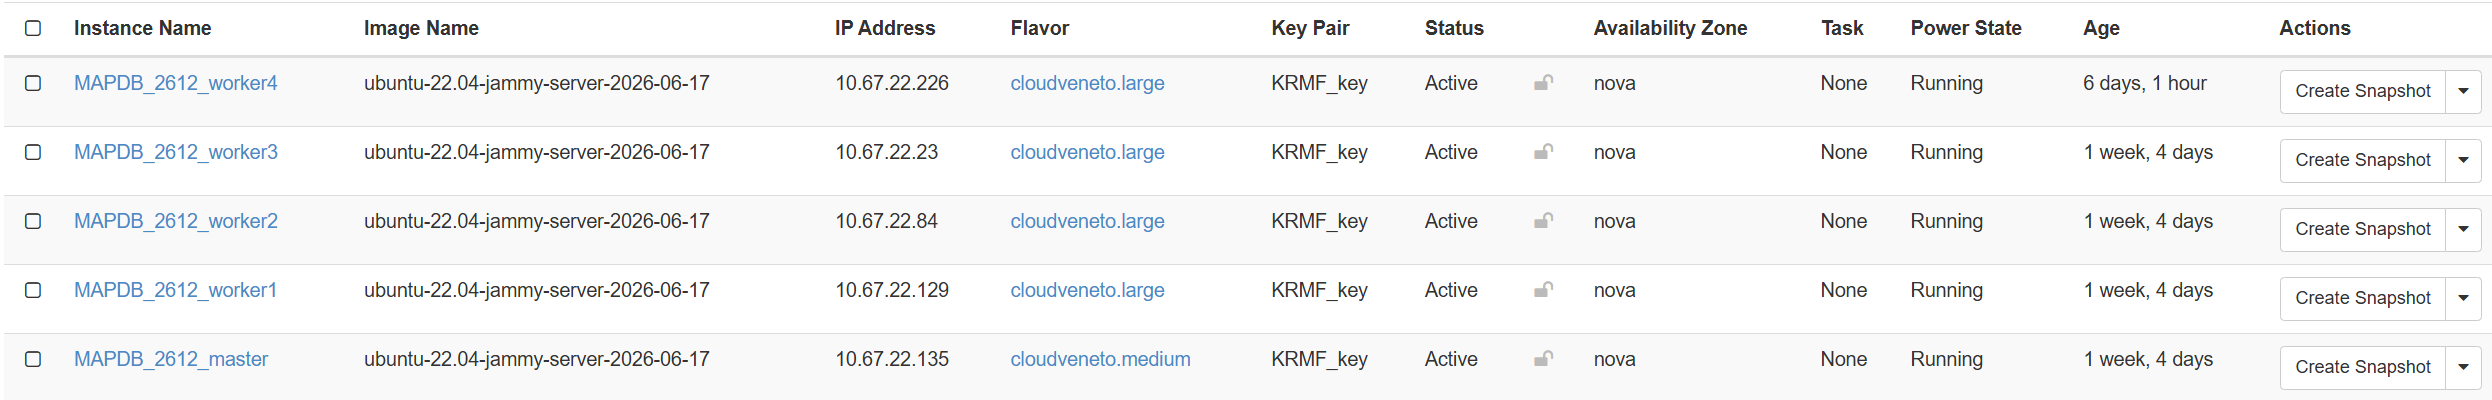

The deployed cluster configuration is summarized below:

| Node Name          | Role        | IP Address      | vCPUs | RAM (GB) |
|--------------------|-------------|-----------------|-------|----------|
| MAPDB_2612_master  | Head node   | 10.67.22.135    | 2     | 4        |
| MAPDB_2612_worker1 | Worker node | 10.67.22.129    | 4     | 8        |
| MAPDB_2612_worker2 | Worker node | 10.67.22.84     | 4     | 8        |
| MAPDB_2612_worker3 | Worker node | 10.67.22.23     | 4     | 8        |
| MAPDB_2612_worker4 | Worker node | 10.67.22.226    | 4     | 8        |

Those IPs must be reported in the file `ips.env`, which defines some environmental variables needed to launch all scripts and distributed computing over the selected nodes.


### 1.2 Spark deployment and configuration




After launching the instances, we installed the required dependencies and configured Spark across all nodes following the CloudVeneto deployment guide for Apache Spark. Per each application the head node is reserved for `SparkContext` initialization in which will be coordinated `Driver`, while all worker nodes are dedicated to parallel task execution. This separation avoids driver overload and improves cluster stability during benchmark runs.

> **Note**
>
> We intentionally excluded the head node from the worker pool, as running both the Spark driver and executor workloads on the same machine introduced excessive memory pressure and reduced available resources for task execution, given the limited RAM capacity of the head node.


### 1.3 Cluster Setup




Before launching Spark applications for Mini Batch K-Means computation and evaluation, you need to create a dedicated Python virtual environment with all required dependencies, which are listed in the `packages.txt` file. 

To do this, simply run the `setup.sh` script. It supports two modalities:

- **localhost**: if no IPs are specified in `ips.env`, the environment is created locally
- **distributed**: if IPs are specified, the environment is created on the master node and then copied to workers

This allows you to run the code either locally or on specified (pre-configured) nodes.

> **Note**
>
> A summary of the necessary steps to properly run scripts following our workflow is available in `instructions.md`.

## 2. RCV1 Dataset



The dataset selected for this work is **RCV1 (Reuters Corpus Volume I)**, one of the benchmark datasets available through `scikit-learn`. RCV1 is a collection of more than 800,000 manually categorized Reuters newswire stories, widely used as a reference dataset for text classification and clustering research.


### 2.1 Dataset Exploration




The dataset can be loaded using the built-in function `sklearn.datasets.fetch_rcv1`, which returns a dictionary-like object containing both the document representations and their associated labels.

The documents are stored in the sparse matrix `rcv1.data`, having shape

\[
 **(804414, 47236)** 
\]

where each of the 804,414 rows represents a news article and each of the 47,236 columns corresponds to a textual feature extracted from the corpus. The feature values encode the importance of each term within a document, providing a high-dimensional sparse representation of its semantic content.

The corresponding labels are stored in `rcv1.target`. Each document may belong to one or more of the 103 available topic codes, represented through a multi-label binary encoding: a value of 1 indicates membership to a topic, whereas 0 indicates no association.

According to *RCV1: A New Benchmark Collection for Text Categorization Research*, the 103 topic codes are organized hierarchically into four top-level categories:

- **CCAT** – Corporate/Industrial
- **ECAT** – Economics
- **GCAT** – Government/Social
- **MCAT** – Markets

Since these represent the highest level of semantic organization, we fix

\[
 **k=4** 
\]

as the number of clusters for all K-Means experiments.

Although K-Means is an unsupervised algorithm, the availability of ground-truth labels allows us to quantitatively evaluate the clustering quality using external validation metrics.

> **Note**
>
> RCV1 is inherently a **multi-label** dataset: a single article may belong to multiple topic categories simultaneously. Since K-Means assigns each sample to exactly one cluster, the evaluation phase is performed on a filtered subset containing only documents associated with a single top-level category.


### 2.2 Dataset Generation and Distribution




After configuring the computing cluster, the dataset preprocessing pipeline is executed through the script `data_generation.py`.

The pipeline consists of four main stages.


#### 2.2.1 Fetching and Label Extraction

The RCV1 dataset is downloaded from `scikit-learn`. For every document, the original topic codes are mapped to their corresponding top-level category (CCAT, ECAT, GCAT or MCAT), producing the macro-labels that will later be used exclusively for evaluation.

#### 2.2.2 Dimensionality Reduction

The original dataset contains more than **47,000 sparse features** per document, making direct clustering computationally expensive while also suffering from the curse of dimensionality.

To obtain a compact latent representation, we employ **Truncated SVD (Latent Semantic Analysis)**. The decomposition is first fitted on a random subset of 50,000 documents:

```python
np.random.seed(42)

sample_idx = np.random.choice(
    rcv1.data.shape[0],
    size=50000,
    replace=False
)

X_sample = rcv1.data[np.sort(sample_idx)]

svd = TruncatedSVD(
    n_components=100,
    random_state=16
)

svd.fit(X_sample)
```

The number of latent dimensions was selected by analyzing the cumulative explained variance.

After several experiments, **100 latent components** were found to provide a good compromise between information preservation and computational efficiency, corresponding approximately to the elbow of the cumulative explained variance curve.

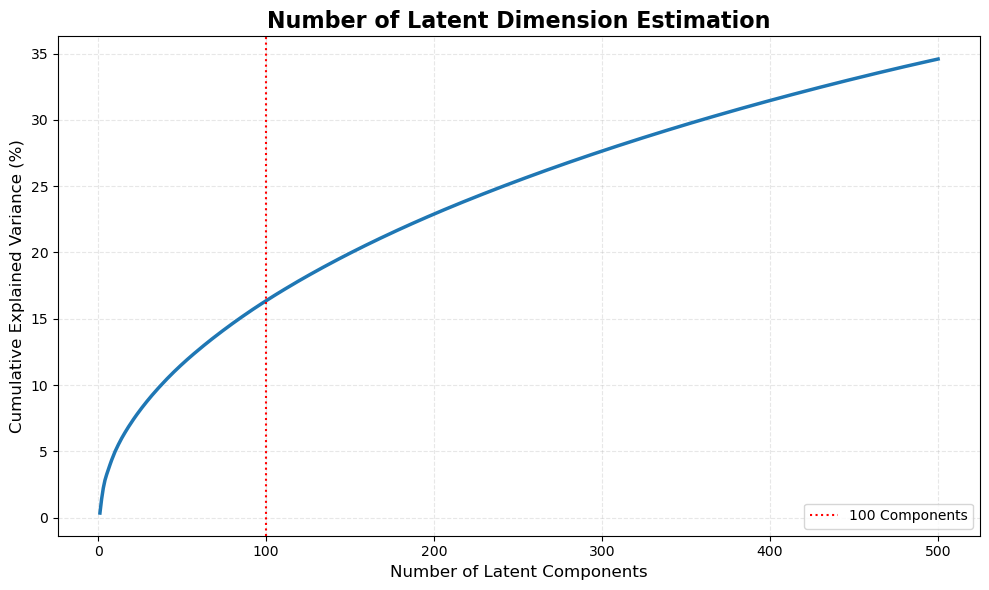


#### 2.2.3 Chunk Processing and Storage




The complete dataset is processed incrementally in batches of 10,000 documents to limit memory consumption.

For each batch:

- the sparse vectors are projected into the latent space;
- the latent vectors are L2-normalized;
- the corresponding macro-labels are attached;
- the batch is stored as a Parquet file.

```python
batch_size = 10000

for start in range(0, n_docs, batch_size):

    X_batch = rcv1.data[start:start+batch_size]

    X_dense = svd.transform(X_batch)

    X_norm = normalize(X_dense, norm="l2", axis=1)

    df_chunk = pd.DataFrame({
        "features": list(X_norm),
        "true_labels": macro_labels[start:start+batch_size]
    })
```

L2 normalization is particularly important because document vectors may differ significantly in magnitude depending on article length. By normalizing each feature vector to unit norm, the clustering process becomes primarily influenced by semantic direction rather than vector magnitude, making cosine similarity effectively equivalent to Euclidean distance in the normalized space.

Finally, each batch is stored as a separate **Parquet** file. Parquet provides compact storage, fast sequential reading, and is naturally suited for distributed processing.

In addition to the complete dataset, a filtered evaluation dataset containing only single-label documents is generated using the same chunking strategy.

The resulting directory structure is

```text
data/
├── rcv1_dataset/
│   ├── part_000.parquet
│   ├── ...
│   └── part_079.parquet
└── evaluation_dataset/
    ├── part_000.parquet
    ├── ...
    └── part_079.parquet
```


#### 2.2.4 Dataset Distribution




When the script is executed on a computing cluster, the dataset is first generated on the head node and then copied to every worker node.

The entire processed dataset occupies only about **1.2 GiB**:

```bash
$ du -sh Project/data
1.2G    Project/data
```

Because of its relatively small size, replicating the dataset on every worker proved to be a simple and effective solution, avoiding the overhead associated with distributed storage systems.

Although this approach does not maximize horizontal scalability, it is entirely adequate for the computational resources and dataset size considered in this project.

For substantially larger datasets, a more scalable architecture would distribute different partitions across worker nodes through a distributed file system (e.g. HDFS), allowing Spark to exploit data locality.

As an additional experiment beyond the scope of the project, we also implemented a version based on **CloudVeneto Object Storage**, compatible with the Amazon S3 API. In this configuration, all workers access the dataset directly from the shared object store instead of maintaining local copies. The corresponding implementation is available in the project's GitHub repository ("kevin" branch).

## 3. Workflow and Implementation



This section presents the execution workflow and the code organization adopted for training and evaluating the Mini-Batch K-Means algorithm using Apache Spark.


### 3.1 Workflow




The main entry point of the Spark application is the shell script `run_script.sh`, which is responsible for configuring the execution environment and submitting the selected Python application to the cluster.

Instead of implementing the whole workflow inside a single Jupyter Notebook, we decided to adopt a script-based approach. This choice provides a more reliable execution environment for long-running experiments, avoiding possible kernel crashes due to memory consumption and improving reproducibility.

The `run_script.sh` script receives as input a Python file, referred to as the **target script**, which contains the actual Spark application logic.

Before execution, the script:

- loads the configuration parameters from `ips.env`;
- activates the required Python virtual environment;
- identifies whether the execution is local or distributed;
- submits the Spark application using the appropriate `spark-submit` configuration.

Depending on the cluster configuration, two execution modes are available.


#### 3.1.1 Local Execution




When no cluster IPs are specified in `ips.env`, the application is executed locally on a single machine.

```bash
# No need to define executors since Spark uses the resources of the local machine
spark-submit \
    --master "local[8]" \
    --driver-memory 4G \
    --py-files functions.py \
    $TARGET_SCRIPT
```

In this configuration:

- `--master "local[8]"` runs Spark locally using 8 available threads;
- `--driver-memory 4G` allocates 4 GB of RAM to the driver process;
- `--py-files functions.py` distributes the additional Python module required by the application;
- no executors are explicitly defined, since all computations are performed by the local Spark process.

---


#### 3.1.2 Distributed Execution




When the cluster IP addresses are provided, the same application is submitted to the distributed Spark cluster. Below, we present one representative configuration among the different setups tested during the processing and benchmarking phases.

```bash
spark-submit \
  --master spark://$MASTER_IP:7077 \
  --driver-memory 5G \
  --executor-memory 2G \
  --conf spark.executor.memoryOverhead=2048M \
  --conf spark.memory.fraction=0.8 \
  --conf spark.memory.storageFraction=0.7 \
  --total-executor-cores 16 \
  --executor-cores 4 \
  --conf spark.eventLog.enabled=true \
  --conf spark.eventLog.dir=file:///tmp/spark-events \
  --py-files functions.py \
  $TARGET_SCRIPT
```

In this configuration:

- `--master spark://$MASTER_IP:7077` connects the application to the Spark master node;
- `--driver-memory 5G` allocates memory to the driver process running the Spark application;
- `--executor-memory 2G` assigns 2 GB of memory to each executor;
- `spark.executor.memoryOverhead=2048M` reserves additional memory outside the JVM heap for executor operations;
- `spark.memory.fraction=0.8` allocates 80% of executor memory to Spark-managed memory;
- `spark.memory.storageFraction=0.7` defines the fraction of Spark memory reserved for storage operations (e.g., caching);
- `--total-executor-cores 16` limits the total number of CPU cores used by executors;
- `--executor-cores 4` assigns 4 cores to each executor;
- `spark.eventLog.enabled=true` enables Spark event logging;
- `spark.eventLog.dir=file:///tmp/spark-events` specifies where execution logs are stored;
- `--py-files functions.py` distributes the required auxiliary code to all worker nodes.

The application is launched with:

```bash
./run_script.sh TARGET_SCRIPT.py
```

The two scripts have complementary roles:

- `run_script.sh` manages the execution environment and Spark application submission;
- `TARGET_SCRIPT.py` contains the actual implementation of the Spark workload.

Inside the target script, the `SparkSession` is created, initializing the `SparkContext`. The driver process is responsible for coordinating execution, creating the computational graph, and scheduling tasks, while the worker nodes execute the parallel computations through their Spark executors.

This separation allows the same cluster configuration to be reused for different experiments by simply changing the target script, improving modularity and reproducibility.

### 3.2 Implementation of clustering algorithms



Here we describe the Spark-parallelized implementation of both the classic and the Mini-batch versions of the $k$-Means algorithm.

> **Note**
>
> All the functions described in this notebook can be consulted in the file **functions.py**. Not all the functions that appear in the file have been illustrated here. We just focused on the most important ones, which are crucial to understand the workflow and the core content of the project.

We first implemented the classic version of the algorithm in the `classic_kmeans` function reported below.

In this function, we start with the `.takeSample` action to initialize `k` centroids by drawing `k` random points from the dataset.

During each step of the following `for` loop:

1. First, the centroids are broadcast to the Executors.
2. Then, the map-reduce transformations `.map` and `.reduceByKey` are used to assign each point to the closest cluster (this makes use of the custom function `closest_idx`) and compute the vector sums and point count needed to obtain the new centroids.
3. Finally, these are returned to the Driver with the `.collect()` action, where the new centroids are eventually computed.

The old broadcast variable is erased from the Workers' memory using `.destroy()`.

```python
def classic_kmeans(rdd_train, k: int, epochs: int, seed: int):
    """Executes the standard K-Means algorithm using Spark."""

    # Initialize centers randomly from training set
    centers = rdd_train.takeSample(False, k, seed)
    
    for _ in range(epochs):
        #Broadcast
        centers_np = np.array(centers)
        bc_centers = rdd_train.context.broadcast(centers_np)
        
        # Map using the broadcasted variable, returns -> (center_idx, (point,count)) of course count will always be 1
        mapped_points = rdd_train.map(lambda x: (closest_idx(x, bc_centers.value), (x, 1)))
        
        # Reduce by key (center_idx) and gives -> (center_idx, (vectorial_sum, population))
        reduced_points = mapped_points.reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
        
        # Update centers and gives them to master -> (center_idc, vectorial_sum/population)
        new_centers_rdd = reduced_points.map(lambda x: (x[0], x[1][0] / x[1][1]))
        new_centers_dict = dict(new_centers_rdd.collect())
        
        # Update centers for next iteration
        centers = [new_centers_dict.get(i, centers[i]) for i in range(k)]
        bc_centers.destroy()

Then, we implemented the Mini-batch version.

This approach employs small batches to optimize the classic algorithm.

We started from the version proposed by D. Sculley in *Web-scale k-means clustering*., whose pseudocode is reported below.

This introduces a gradient-descent approach, with the introduction of a learning rate term $\eta$ that is updated point-by-point at each step during the inner `for` loop over the batch.

**Algorithm 1:** Mini-batch $k$-Means.
***
1. **Given:** $k$, mini-batch size $b$, iterations $t$, data set $X$
2. Initialize each $\mathbf{c} \in C$ with an $\mathbf{x}$ picked randomly from $X$
3. $\mathbf{v} \leftarrow 0$
4. **for** $i = 1$ to $t$ **do**
5. &nbsp;&nbsp;&nbsp;&nbsp; $M \leftarrow b$ examples picked randomly from $X$
6. &nbsp;&nbsp;&nbsp;&nbsp; **for** $\mathbf{x} \in M$ **do**
7. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\mathbf{d}[\mathbf{x}] \leftarrow f(C, \mathbf{x})$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; *// Cache the center nearest to $\mathbf{x}$*
8. &nbsp;&nbsp;&nbsp;&nbsp; **end for**
9. &nbsp;&nbsp;&nbsp;&nbsp; **for** $\mathbf{x} \in M$ **do**
10. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\mathbf{c} \leftarrow \mathbf{d}[\mathbf{x}]$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; *// Get cached center for this $\mathbf{x}$*
11. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\mathbf{v}[\mathbf{c}] \leftarrow \mathbf{v}[\mathbf{c}] + 1$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; *// Update per-center counts*
12. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\eta \leftarrow \frac{1}{\mathbf{v}[\mathbf{c}]}$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; *// Get per-center learning rate*
13. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\mathbf{c} \leftarrow (1 - \eta)\mathbf{c} + \eta\mathbf{x}$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; *// Take gradient step*
14. &nbsp;&nbsp;&nbsp;&nbsp; **end for**
15. **end for**
***

We then implemented the Spark-parallelized version of the Mini-batch $k$-Means algorithm.

First, the centroids are initialized randomly using the `.takeSample` action, and the historical count array `v` is initialized to zero.

The `fraction` parameter, which quantifies the percentage of samples per batch, is then computed by employing the `.count()` action.

During the following `for` loop:

1. The centroids are broadcast to the Executors, and a random mini-batch is drawn from the dataset using the `.sample()` transformation.
2. Map-reduce transformations (`.map` and `.reduceByKey`) are then employed to assign the points to the nearest centroid and to compute the vector sums and point counts for each cluster.
3. These are then returned to the Driver via the `.collect()` action.
4. Finally, the centroids are computed with a gradient step: for each cluster, the historical volume `v` is updated and the learning rate $\eta$ is calculated. The centroid is moved towards the center of the current batch according to this learning rate.

Lastly, the broadcast variable is destroyed to free the memory.

```python
def minibatch_kmeans(rdd_train, k: int, b: int, epochs: int, seed: int):
    """Executes the Mini-Batch K-Means algorithm using Spark."""
    centers_list = rdd_train.takeSample(False, k, seed)
    centers = np.array(centers_list) 
    
    v = np.zeros(k)
    
    # Calculate fraction for Spark's .sample()
    total_count = rdd_train.count()
    fraction = min(1, float(b)/total_count)
    
    for epoch in range(epochs):
        # Broadcast the centers
        bc_centers = rdd_train.context.broadcast(centers)
        
        # Distributed sampling on workers
        rdd_batch = rdd_train.sample(False, fraction)
        
        # Distributed mapping --> (cluster_idx: (point,1))
        mapped_batch = rdd_batch.map(
            lambda x: (closest_idx(x, bc_centers.value), (x, 1))
        )
        
        # Distributed reduction, collecting only the k aggregates
        reduced_batch = mapped_batch.reduceByKey(
            lambda a, b: (a[0] + b[0], a[1] + b[1])
        ).collect()
        
        # Local update on the Driver 
        for c_idx, (sum_x, count) in reduced_batch:
            v[c_idx] += count               
            eta = count / v[c_idx]          
            batch_mean = sum_x / count      
            centers[c_idx] = (centers[c_idx] * (1.0 - eta)) + (batch_mean * eta)
            
        bc_centers.destroy()
        
    return centers.tolist()

### 3.3 Tuning of the `b` Hyperparameter



The Mini-batch $k$-Means algorithm requires specifying the mini-batch size `b` as an input parameter in the `minibatch_kmeans` function, as described in the previous "Spark-parallelized Implementation of Clustering Algorithms" section. In order to choose the optimal value for this parameter, we introduced the `b_search` function, which performs a grid search over a list of candidate values for `b`. Before detailing the `b_search` function, we first illustrate the implementation of two clustering metrics that were utilized to implement it.



#### 3.3.1 Clustering Metrics: WCSS and Calinski-Harabasz Index




The first clustering metric we illustrate in this subsection is the **Within-Cluster Sum of Squares ($WCSS$)**. It calculates the sum of the squared Euclidean distances between every data point and the centroid of the cluster to which it is assigned, measuring the intra-cluster variance:

$$
WCSS = \sum_{k=1}^K\sum_{x_i \in C_k} \|\ \mathbf{x_i} - \mathbf{\mu}_k\|^2,
$$

where:

* $\{x_i\}_{C_k}$ are the points assigned to the cluster $C_k$,
* $\mu_k$ is the centroid of the $k$-th cluster,
* $K$ is the total number of clusters.

In the `WCSS` function, we introduced a map-reduce approach to compute the $WCSS$ given an RDD and a list of centroids.


```python
def WCSS(rdd_test, centers: list) -> float:
    """Calculates the Within-Cluster Sum of Squares (WCSS) for cost evaluation"""
    centers_np = np.array(centers)
    
    # Broadcasts centers to executors
    bc_centers = rdd_test.context.broadcast(centers_np)
    
    wcss = rdd_test.map(
        lambda x: float(np.sum((x - bc_centers.value[closest_idx(x, bc_centers.value)]) ** 2))
    ).sum()
    
    #Clean executors RAM
    bc_centers.destroy()

    return wcss
```

The second clustering metric we made use of is the **Calinski-Harabasz index ($CH$)**. This metric computes the ratio of the normalized versions of the Within-Cluster Sum of Squares($WCSS$) and the Between-Cluster Sum of Squares ($BCSS$):
$$
    CH = \frac{BCSS/(K-1)}{WCSS/(n - K)},
$$
where:
* $WCSS$ is the Within-Cluster Sum of Squares,
* $n$ is the number of data points,
* $K$ is the total number of clusters,
* $BCSS$ is the Between-Cluster Sum of Squares, defined as:
    $$
        \sum_{k=1}^K n_k \|\ \mathbf{\mu_k} - \mathbf{\mu}\|^2,
    $$
    where:
    - $n_k$ is the number of points in cluster $C_k$,
    - $\mu_k$ is the centroid of cluster $C_k$,
    - $\mu$ is the global centroid, defined as $\frac{1}{n}\sum_{i=1}^n \mathbf{x_i}$.

It is worth noting that $WCSS$ and $BCSS$ are linked by the Law of Total Variance to the Total Sum of Squares ($TSS$):
$$
    TSS \doteq \sum_{i = 1}^n \|\ \mathbf{x_i} - \mathbf{\mu}\|^2 = WCSS + BCSS.
$$
In the `calinski_harabasz` function, we exploit Spark transformations and actions to compute these quantities across the cluster, making use of the aforementioned formulas.

```python
def calinski_harabasz(rdd_test, centers: list, k: int) -> float:
    """Calculates the Calinski-Harabasz Index for best_b identification"""
    N = rdd_test.count()
    
    # Compute gloabl centroid by summing all point vectors and dividing by N
    global_sum = rdd_test.reduce(lambda a, b: a + b)
    global_mean = global_sum / float(N)
    
    # Total Sum of Squares. We use total variance rule to get BCSS later (TSS = BCSS + wcss_score)
    bc_global_mean = rdd_test.context.broadcast(global_mean)

    # Sum of Squares between each point of test set and global center found
    tss = rdd_test.map(
        lambda x: float(np.sum((x - bc_global_mean.value) ** 2))
    ).sum()

    #Clean executors RAM
    bc_global_mean.destroy()
    
    #Evaluates wcss_score using designed functions
    wcss = WCSS(rdd_test, centers)
    
    #BCSS Evaluation
    bcss = tss - wcss
    
    # Avoid zero divisions (just in case)
    if wcss == 0:
        return float('inf')
    
    # Final Index
    ch_score = (bcss / (k - 1)) / (wcss / (N - k))
    
    return ch_score
```


#### 3.3.2 Function `b_search` for the Tuning of the `b` Parameter




We can finally detail the `b_search` function. The objective of this function is to find the optimal value for the mini-batch size `b` by performing a grid search. We report below a trimmed version of the full function (which can be consulted in the `functions.py` file), to highlight the core loops and operations involved. Some parts, e.g. the ones regarding metadata logging and the DataFrames operations, have been omitted for brevity.

After train-test split and data caching, the algorithm implements a nested `for` loop. The outer loop runs `num_iter` iterations to ensure statistical robustness. The inner loop iterates on the candidate values of `b`. At each iteration of the inner loop, the model is trained by calling the `minibatch_kmeans` function, and its performance is then evaluated by computing the $CH$ index on the test set, exploiting the `calinski_harabasz` function. Both the score and the execution time are recorded for each configuration.

The optimal value of `b` is then selected by grouping batch sizes within a $2%$ tolerance of the maximum $CH$ score, averaged on the iterations, and picking the one with the smallest execution time.

```python
def b_search(rdd_sample, K, b_list, epochs, num_iter, raw_csv, stats_csv):
    """Grid Search to find best b parameter among list of values"""

    # Tracks total time of the search
    start = time.time()

    # Empty list to store results of every iteration
    results = []

    #pySpark function to split the dataset in training set (80%) and test set (20%)
    rdd_train, rdd_test = rdd_sample.randomSplit([0.8, 0.2], seed=1)

    # Cache the RDDs in memory for the rest of the function
    rdd_train.persist() 
    rdd_test.persist()  

    # Actions to trigger the cache on worker's RAM
    train_size = rdd_train.count() 
    test_size = rdd_test.count()
    
    for run_id in range(num_iter):

        for b in b_list:

            print(f'Testing Mini-Batch Size={b}, iteration:{run_id}')

            #Tracks time of a single iteration
            start_time = time.time()
            centers = minibatch_kmeans(rdd_train, K, b, epochs, seed=run_id)
            exec_time = time.time() - start_time
            
            #Evaluates The evaluation index using the test set and the centers found
            ch_score = calinski_harabasz(rdd_test, centers, K)
            
            # [ ... Data logging ... ]

    # Empty the cache to free up memory on the executors  
    rdd_train.unpersist()
    rdd_test.unpersist()


    # [ ... Pandas aggregation ... ]
    
    # Introduce a tolerance threshold to evaluate only a few CH index vaues in terms of time performance
    best_ch_score = df_stats['mean_ch'].max()
    tolerance = 0.020
    accepted_ch = best_ch_score * (1.0 - tolerance)
    mask_ch = df_stats['mean_ch'] >= accepted_ch

    #Filter the DataFrame and takes only CH values above the threshold
    accepted_batch = df_stats[mask_ch]
    # best_b is the one that minimizes run time among those values
    mask_b = accepted_batch['mean_time'].idxmin()
    best_b = accepted_batch.loc[mask_b, 'batch_size']
    
    # Stop time for the whole grid search
    duration = time.time() - start

    # [... Metadata logging ...]

    return int(best_b), df_stats
```

In the following dispersion plot the best MiniBatch size can be found graphically.


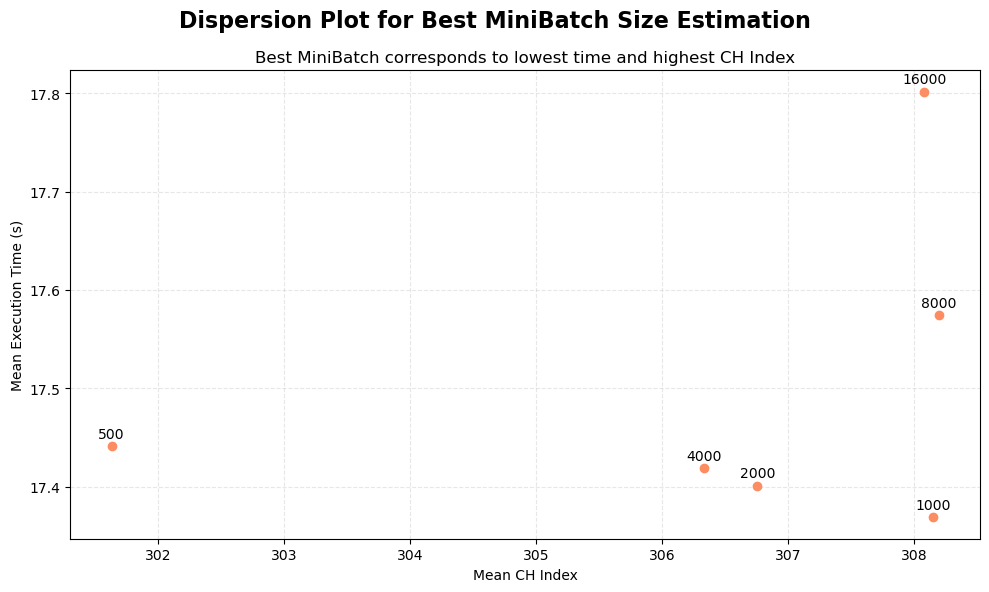

### 3.4 Running of the Algorithms




To run the entire experiment and retrieve the results, the functions `mini_batch_run` and `classic_kmeans_run` were introduced. In this section, we'll limit ourselves to illustrating the workflow of the former, as the two functions are extremely similar one to another. We report below a trimmed version of the full function (which can be consulted in the `functions.py` file), to highlight the core loops and operations involved. Some parts, e.g. the ones regarding metadata logging and the DataFrames operations, have been omitted for brevity.

After the initialization of lists and utility variables and a deterministic train-test split (to ensure a fair comparison across different algorithms), the training and testing RDDs are cached into the Executors' RAM. We encounter the core section of the `mini_batch_run` function, i.e. the `for` loop. During each iteration of this loop, the `minibatch_kmeans` function is called to compute the centroids. The internal seed is varied at each run to ensure the random initialization of the centroids. The execution time is recorded for each training step, and the performance of the model is obtained by computing the $WCSS$ on the test set, exploiting the `WCSS` function. The best model is chosen to be the one minimizing the $WCSS$.

```python
def mini_batch_run(rdd_data, K, best_b, epochs, num_iter, raw_csv, stats_csv):
    """Runs the final mini batch k-means using the discovered optimal parameters"""

    # [ ... Initialization of lists and variables ...]

    #pySpark function to split the dataset in training set (80%) and test set (20%)
    rdd_train, rdd_test = rdd_data.randomSplit([0.8, 0.2],seed=18)

    #Cache the RDDs in memory for the rest of the function
    rdd_train.persist() 
    rdd_test.persist()  

    # Actions to trigger the cache on worker's RAM
    train_size = rdd_train.count() 
    test_size = rdd_test.count()
    
    for run_id in range(num_iter):
        print(f"MiniBatch K-means, {epochs} epochs -- Iteration: {run_id}")
        
        # Time of single iteration
        start_time = time.time()
        centers = minibatch_kmeans(rdd_train, K, best_b, epochs, seed=run_id)
        exec_time = time.time() - start_time
        
        #Evaluates cost function
        wcss = WCSS(rdd_test, centers)

        #Update best values if current wcss is lower than previous best
        if wcss < best_wcss:
            best_wcss = wcss
            best_centers = centers
            best_run_id = run_id
        
        # [ ... Append of results ...]
        
    # Free up cahched memory
    rdd_train.unpersist()
    rdd_test.unpersist()

    # [... Pandas aggregation and logging of metadata ... ]
    
    return df_stats
```


### 3.5 Clustering Diagnostic




Once we've retrieved the Champion model running the algorithm with the optimal value for the hyperparameter `b`, the `cluster_diagnostic` function can be used to assess the clustering performance against the ground truth. This function allows to measure the agreement between the discovered clusters and the true labels of the datasets. To do this, the Normalized Mutual Information score (NMI) was used.

We report a streamlined version of the function below, highlighting its core operations.

```python
def cluster_diagnostic(rdd_data, champion_centers, plot_csv):
    """Evaluates Champion Model of a run against the ground truth labels"""

    #Tracks evaluation time
    start = time.time()

    
    # Convert the centers to a numpy array and broadcaste them
    centers_np = np.array(champion_centers)
    bc_centers = rdd_data.context.broadcast(centers_np)

    # Function to create tuple (real_label, predicted_label)
    def predict_label(row):
        # Converts feature in array
        point = np.array(row['features'])

        #Assigns every point (document) of the evaluation dataset to a cluster using the champion centers
        pred = closest_idx(point, bc_centers.value)
    
        return (row['true_labels'], pred)

    #Applies the funtion to the evaluation dataset using map and then collect the results
    labels_rdd = rdd_data.map(predict_label)
    labels_local = labels_rdd.collect()

    # Extracts true and prediceted labels for evaluation
    labels_true = [x[0] for x in labels_local]
    labels_pred = [x[1] for x in labels_local]
    
    print("Evaluating Clustering Performance...")
    # Calcultae NMI using sklearn function
    nmi_score = NMI(labels_true, labels_pred)
    # Lenght of the evaluation dataset to calculate fraction of points to sample
    evaluated_documents = len(labels_true)
    
    #To visualize clusters we just need a few points -> sampling with pyspark sample() function
    fraction = min(1, 5000/evaluated_documents)
    sampled_rows = rdd_data.sample(False, fraction).collect()


    # [ ... Pandas conversion, logging of metadata, plot preparation ... ]
    
    print(f'NMI Score: {nmi_score}')
    
    bc_centers.destroy()
```

## 4. Results and Benchmarks

### 4.1 Algorithm Benchmarks



We evaluated three different types of Mini-Batch K-Means performance benchmarks across different Spark Application cluster configurations used to parallelize the computation. They are reported below.

#### 4.1.1 Topology Benchmark



We identified three different topology configurations with which we ran the algorithm. For each configuration, we performed 50 iterations to obtain statistical results. The observable evaluated is the **Execution Time**.

The three topology config considered, given our total 16 cores, are:

- **Thin:** 16 total executors (four per node with 1 cores)
- **Balanced:** 8 total executors (two per node with 2 cores)
- **Fat:** 4 total executors (one per node with 4 cores)



Firstly, a box plot is presented to compare the execution time distributions across all iterations for the different topology configurations.

<div align="center">
<img src="images/TopBox.png" width="900">
</div>

Then, we plotted the execution time over the 50 iterations as a line plot to analyze the performance variability during the executions.

<div align="center">
<img src="images/TopIter.png" width="900">
</div>

Finally, a box plot is presented to compare the mean execution time among the different topology configurations.

<div align="center">
<img src="images/TopBar.png" width="900">
</div>


#### 4.1.2 Partitions Benchmark



We then evaluated the algorithm performance using the **Fat** topology (the best configuration identified previously) with different numbers of partitions for the parallelized DataFrame containing the processing data. The selected number of partitions are:

```python
partitions = [4, 8, 16, 32, 48, 64, 80, 96]
```

The **Execution Time** observable was evaluated over 50 iterations for each partition configuration.

Initially, we compared the mean execution time across the different numbers of partitions.

<div align="center">
<img src="images/Partitions.png" width="900">
</div>

Then, we plotted the execution time versus iteration for the 48, 64, 80, and 96 partition cases to analyze performance fluctuations, as these configurations showed the largest variations.

<div align="center">
<img src="images/PartitionsIter.png" width="900">
</div>

We conclude that, given the **Fat** topology, 16 partitions provide the best performance.


#### 4.1.3 Strong Scaling



Here, given 4 PUs per executor, we evaluated the performance in terms of Execution Time by comparing an increasing number of executors (from 1 to 4). In particular, we added a working node with a Fat topology at each step. As before, 50 iterations were performed for statistical analysis.

For consistency, we selected 48 partitions, corresponding to the minimum common multiple of 4, 8, 12, and 16 cores. This avoids disadvantages due to non-divisible partitions, which could leave some tasks waiting at the end of the computation. Although 48 partitions is not the optimal configuration in terms of execution time, it allows a fair comparison between different executor configurations.

Firstly, we report a bar plot of the mean execution time.

<div align="center">
<img src="images/SCBar.png" width="900">
</div>

Then, we evaluated the relative **Speed-Up**, defined as:

$$
S(n) = \frac{\bar{t}(1)}{\bar{t}(n)}
$$

and compared it with the theoretical scaling models according to Amdahl's and Gustafson's Laws (assuming (p=1)).

<div align="center">
<img src="images/SCSpeedUp.png" width="900">
</div>

We conclude that adding PUs effectively speeds up the computation and stabilizes the execution time across iterations.


#### 4.1.4 Weak Scaling



We evaluated the consistency of the parallelization framework through a weak scaling analysis. The objective is to verify how the **Mean Execution Time** changes when both the computational resources and the dataset size are increased proportionally.

In particular, we increased the number of executors (with 4 PUs each, as in the strong scaling experiment) while proportionally increasing the number of samples and partitions:

* 1 executor (4 cores) processing 200k samples with 4 partitions
* 2 executors (8 cores) processing 400k samples with 8 partitions
* 3 executors (12 cores) processing 600k samples with 12 partitions
* 4 executors (16 cores) processing 800k samples with 16 partitions

The results are reported below:

<div align="center">
<img src="images/WK.png" width="900">
</div>

The results show that the execution time remains approximately constant as the workload and the available computational resources increase proportionally.


### 4.2 Algorithm Comparison (Strong Scaling)



We then compared Mini-Batch K-Means with Classic K-Means, implemented as previously described and evaluated under the same configuration. In particular, we compared the mean execution time as a function of the number of executors, considering a 50-iteration experiment for each configuration.

The results are reported below.

<div align="center">
<img src="images/Comparison.png" width="900">
</div>

As expected, Mini-Batch K-Means achieves better performance in terms of computational time. The improvement is already noticeable with only one executor. This is due to the fact that Classic K-Means is itself well suited for parallelization, resulting in competitive performance. The observed improvements range from a few seconds up to approximately 30 seconds.

According to "Sculley, D. (2010), *Web-scale k-means clustering*", significant gains from Mini-Batch K-Means are expected for very large-scale datasets. The obtained results are consistent with the fact that RCV1 is a large, but not extremely large, dataset.


### 4.3 Clustering Evaluation



Considering the evaluation dataset, composed of points belonging to only one label, we compared the ground truth labels provided with the dataset (formed by 4 main topic codes) with the clustering assignment obtained from the best iteration among the 50 runs performed using the **Fat** topology with 16 partitions (peak configuration).

To visualize the clustering structure, we further compressed the latent features using t-SNE (t-distributed Stochastic Neighbor Embedding), mapping the original 100-dimensional feature space into a 2-dimensional representation.

The population plot is reported below.

<div align="center">
<img src="images/Population.png" width="900">
</div>

The Normalized Mutual Information score and the corresponding confusion matrix are reported below.

<div align="center">
<img src="images/NMI.png" width="900">
</div>

The comparison shows that 3 out of 4 clusters approximately represent one of the main topics among the selected evaluation points. The **ECAT** topic is not correctly identified, as it is mostly incorporated into cluster 3. Furthermore, cluster 0 does not correspond to any main topic, leading to a lower NMI score, which results in **0.5618**.

We conclude that, using the selected latent representation, our best-performing configuration (**Fat topology with 16 partitions**) is not sufficient to correctly classify RCV1 news articles according to their main topics.


---

#### References

- Sculley, D. (2010). *Web-scale k-means clustering*.
- MAPD-B UniPD course lecture notes.
- Scikit-learn RCV1 dataset: https://scikit-learn.org/0.18/datasets/rcv1.html
- Lewis, D. D., Yang, Y., Rose, T. G., & Li, F. (2004). *RCV1: A new benchmark collection for text categorization research*. Journal of Machine Learning Research, 5, 361-397.
- Apache Spark Parquet documentation: https://spark.apache.org/docs/latest/sql-data-sources-parquet.html
- Scikit-learn TruncatedSVD: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html